<IPython.core.display.Javascript object>


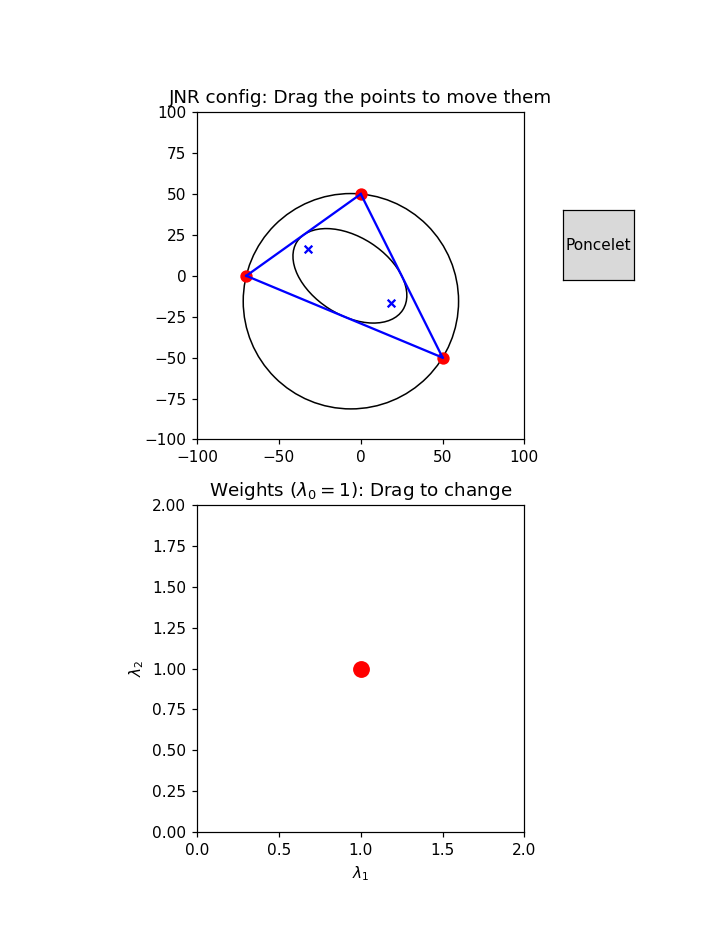

In [2]:
# If running in a personal notebook, change this first line to be
#     %matplotlib notebook
# to make the best use of all the interactive functionality.  
%matplotlib notebook
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Ellipse
from matplotlib.widgets import Button
import numpy as np

#####################################
#####################################
## STOP TO CHANGE THESE IF DESIRED ##
#####################################
#####################################
# Initial points for the triangle
initial_points = np.array([[-70, 0], [0, 50], [50, -50]])
# Initial weights lambda_1 and lambda_2 (lambda_0 scaled to 1). 
initial_weights = [1, 1]

def circle_finder(points):
    # return the center xy = (xc, yc) and radius r of the unique circle
    # through the three points of points.
    # we will assume the point are not all collinear
    
    # We do this simply by solving and using the known formula in certain cases. 
    
    # (xc - x1)^2 + (yc - y1)^2 = (xc - x2)^2 + (yc - y2)^2
    # => -2*x1*xc + x1^2 - 2*yc*y1 + y1^2 = -2*x2*xc + x2^2 - 2*yc*y2 + y2^2
    # => 2*(x2 - x1)*xc + 2*(y2 - y1)*yc = (x2^2 - x1^2) + (y2^2 - y1^2)
    
    # If x2 == x1 solution is easy, so assume otherwise 
    # Likewise with x3 == x1. 
    
    # 2*((y2 - y1)*(x3 - x1) - (y3 - y1)*(x2 - x1))*yc = (x3 - x1)*((x2^2 - x1^2) + (y2^2 - y1^2))
    #                                                   -(x2 - x1)*((x3^2 - x1^2) + (y3^2 - y1^2))
    # Given this solve for xc as before
    x1, y1 = points[0]
    x2, y2 = points[1]
    x3, y3 = points[2]
    
    if x2==x1:
        yc = (y2 + y1)/2
        xc = ((x3**2 - x1**2) + (y3**2 - y1**2) - 2*(y3 - y1)*yc) / (2*(x3 - x1))
        r = np.sqrt((x1 - xc)**2 + (y1 - yc)**2)
        return (xc, yc), r
    
    if x3==x1:
        yc = (y3 + y1)/2
        xc = ((x2**2 - x1**2) + (y2**2 - y1**2) - 2*(y2 - y1)*yc) / (2*(x2 - x1))
        r = np.sqrt((x1 - xc)**2 + (y1 - yc)**2)
        return (xc, yc), r
    
    yc = ((x3 - x1)*((x2**2 - x1**2) + (y2**2 - y1**2)) - (x2 - x1)*((x3**2 - x1**2) + (y3**2 - y1**2)))
    yc /= 2*((y2 - y1)*(x3 - x1) - (y3 - y1)*(x2 - x1))
    xc = ((x3**2 - x1**2) + (y3**2 - y1**2) - 2*(y3 - y1)*yc) / (2*(x3 - x1))
    r = np.sqrt((x1 - xc)**2 + (y1 - yc)**2)
    return (xc, yc), r

def inellipse_finder(vertices, weights):
    # The first step is to identify the points of tangency
    # This is done by solving e.g. 
    # l0/l1 = |a0 - b2|/|b2 - a1|. 
    # To do this write b2 = a0 + t(a1 - a0) for t in [0,1]
    # Then |a0 - b2| = t|a1 - a0|
    #      |b2 - a1| = (1-t)|a1 - a0|
    # So l0/l1 = t/(1-t), 
    #  1/t - 1 = l1/l0, 
    # t = 1/(1 + l1/l0) = l0/(l0 + l1)
    
    # We then use the linear method to get the coefficients of the 
    # ellipse
    # Suppose the ellipse is given by 
    # g = Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0
    # we will construct a matrix which gives equations for the 
    # coefficients
    
    # The first three equations are simply that the tangency points
    # lie on the ellipse
    
    # To find the tangency equations we need that the tangent vector
    # to the ellipse at the tangency point is orthogonal to the 
    # corresponding edge. We will assume tps and vertices are 
    # correspondingly ordered. 
    # Consider the tangency point b2 along the edge from vertices
    # a0 to a1. The tangent to the edge is a1 - a0. 
    # Remember that if a curve is given by g = 0, then if v0 is on 
    # the curve 
    # g(v) = g(v0) + <(v - x0), grad(g)> + O((v - v0)^2)
    #      = <(v - v0), grad(g)> to leading order. Hence tangent
    # vectors are orthogonal to grad(g). 
    
    # We can check grad(g) = (2Ax + By + D, 2Cy + Bx + E)
    # Hence we get the equation 
    # (2*X2*(x1-x0))*A + (Y2*(x1-x0)+X2*(y1-y0))*B + (2*Y2*(y1-y0))*C
    # + (x1-x0)*D + (y1-y0)*E = 0
    weights = [1, weights[0], weights[1]]
    tangency_points = []
    intersection_eqns = []
    tangency_eqns = []
    for i in range(3):
        x0, y0 = vertices[i]
        x1, y1 = vertices[(i+1)%3]
        l0 = weights[i]
        l1 = weights[(i+1)%3]
        t2 = l0/(l0 + l1)
        X2 = x0 + t2*(x1 - x0)
        Y2 = y0 + t2*(y1 - y0)
        tangency_points.append([X2, Y2])
        intersection_eqns.append([X2**2, X2*Y2, Y2**2, X2, Y2, 1])
        tangency_eqns.append([2*X2*(x1-x0), Y2*(x1-x0)+X2*(y1-y0),
                              2*Y2*(y1-y0), x1-x0, y1-y0, 0])
    eqns = intersection_eqns + tangency_eqns
    # This is the matrix we want to find the kernel of
    M = np.array(eqns)
    ER = np.linalg.eig(M)
    # This will be the norm-1 e-vector corresponding to e-val zero 
    v = ER[1][:, min(range(len(ER[0])), key = lambda i: np.abs(ER[0][i]))]
    A, B, C, D, E, F = [np.real(vi) for vi in v]
    # https://en.wikipedia.org/wiki/Ellipse
    disc = B**2 - 4*A*C
    xc = (2*C*D - B*E)/disc
    yc = (2*A*E - B*D)/disc
    pf = A*E**2 + C*D**2 - B*D*E + disc*F
    s = np.sqrt((A - C)**2 + B**2)
    a = -np.sqrt(2*pf*(A + C + s))/disc
    b = -np.sqrt(2*pf*(A + C - s))/disc
    th = np.degrees(np.arctan2(-B, C - A)/2)
    
    return (xc, yc), 2*a, 2*b, th

def ellipse_foci(xy, w, h, th):
    
    if w >= h:
        c = np.sqrt(w**2 - h**2)/2
        f1 = [xy[0] + c*np.cos(np.radians(th)), xy[1] + c*np.sin(np.radians(th))]
        f2 = [xy[0] - c*np.cos(np.radians(th)), xy[1] - c*np.sin(np.radians(th))]
    else:
        c = np.sqrt(h**2 - w**2)/2
        f1 = [xy[0] + c*np.cos(np.radians(th)+np.pi/2), xy[1] + c*np.sin(np.radians(th)+np.pi/2)]
        f2 = [xy[0] - c*np.cos(np.radians(th)+np.pi/2), xy[1] - c*np.sin(np.radians(th)+np.pi/2)]    
    return np.array([f1, f2]) 

class JNR_Poncelet_config:
    def __init__(self, ax, points, weights_ax, weights):
        # ax is the axes to plot the config on
        # points are the points of the triangle to initialise at
        # weights are the two ratios lambda2/lambda1 and lambda3/lambda1
        # equivalently we have set lambda1 = 1. 
        self.ax = ax
        self.points = points
        self.lines = [
            Line2D([points[0, 0], points[1, 0]], [points[0, 1], points[1, 1]], color='blue'),
            Line2D([points[1, 0], points[2, 0]], [points[1, 1], points[2, 1]], color='blue'),
            Line2D([points[2, 0], points[0, 0]], [points[2, 1], points[0, 1]], color='blue')
        ]
        for line in self.lines:
            ax.add_line(line)
            
        self.circle = Circle(*circle_finder(self.points), fill=False)
        ax.add_patch(self.circle)

        self.scatter = ax.scatter(points[:, 0], points[:, 1], color='red', s=50, picker=True)
        self._dragging_point = None

        self.ax.figure.canvas.mpl_connect('button_press_event', self.on_button_press)
        self.ax.figure.canvas.mpl_connect('button_release_event', self.on_button_release)
        self.ax.figure.canvas.mpl_connect('motion_notify_event', self.on_motion)
        
        self.weights_ax = weights_ax
        self.weights = weights
        self.weights_scatter = weights_ax.scatter(weights[0], weights[1], color='red', s=100, picker=True)
        
        self.weights_ax.figure.canvas.mpl_connect('button_press_event', self.on_button_press)
        self.weights_ax.figure.canvas.mpl_connect('button_release_event', self.on_button_release)
        self.weights_ax.figure.canvas.mpl_connect('motion_notify_event', self.on_motion)
        
        xy, w, h, ang = inellipse_finder(self.points, self.weights)
        self.ellipse = Ellipse(xy, w, h, angle=ang, fill=False)
        ax.add_patch(self.ellipse)
        
        foci = ellipse_foci(xy, w, h, ang)
        self.foci = ax.scatter(foci[:,0], foci[:,1], color='blue', s=25, marker='x')

    def triangle_updater(self):
        self.scatter.set_offsets(self.points)
        self.lines[0].set_data([self.points[0, 0], self.points[1, 0]], [self.points[0, 1], self.points[1, 1]])
        self.lines[1].set_data([self.points[1, 0], self.points[2, 0]], [self.points[1, 1], self.points[2, 1]])
        self.lines[2].set_data([self.points[2, 0], self.points[0, 0]], [self.points[2, 1], self.points[0, 1]])

    def ellipse_updater(self):
        xy, w, h, ang = inellipse_finder(self.points, self.weights)
        self.ellipse.set_center(xy)
        self.ellipse.set_width(w)
        self.ellipse.set_height(h)
        self.ellipse.set_angle(ang)
        foci = ellipse_foci(xy, w, h, ang)
        self.foci.set_offsets(foci)
        
    def on_poncelet_button(self, event):
        self.infinitesimal_poncelet()

    def infinitesimal_poncelet(self, eps=0.01):
        # uses the infinitesimal deformation to get adjacent triangles. 
        # will eventually deviate. 
        # Method of AM93
        xy = np.array(self.circle.center)
        diffs = [p-xy for p in self.points]
        old_angles = np.array([np.arctan2(d[1], d[0]) for d in diffs])
        old_s = np.tan(old_angles/2)
        weights = np.array([1, self.weights[0], self.weights[1]])
        new_s = old_s + eps*weights*(1 + old_s**2)
        new_angles = 2*np.arctan(new_s)
        r = self.circle.radius
        self.points = np.array([xy+r*np.array([np.cos(th), np.sin(th)]) for th in new_angles])
        self.triangle_updater()
        
    def on_button_press(self, event):
        if (event.inaxes != self.ax) and (event.inaxes != self.weights_ax):
            return
        contains, info = self.scatter.contains(event)
        if contains:
            self._dragging_point = info.get('ind')[0]
            
        contains, info = self.weights_scatter.contains(event)
        if contains:
            self._dragging_point = info.get('ind')[0]

    def on_button_release(self, event):
        self._dragging_point = None

    def on_motion(self, event):
        if self._dragging_point is None:
            return
        
        if event.inaxes == self.ax:
            x, y = event.xdata, event.ydata
            self.points[self._dragging_point] = [x, y]
            self.triangle_updater()

            xy, r = circle_finder(self.points)
            self.circle.set_center(xy)
            self.circle.set_radius(r)
            
            self.ellipse_updater()

            self.ax.figure.canvas.draw_idle()
            
        if event.inaxes == self.weights_ax:
            x, y = event.xdata, event.ydata
            self.weights = [x, y]
            self.weights_scatter.set_offsets(self.weights)
            
            self.ellipse_updater()
            
            self.weights_ax.figure.canvas.draw_idle()

# Set up the plot
fig, (ax1, ax2) = plt.subplots(2, 1)

fig.set_figheight(8.5)

ax1.set_xlim(-100, 100)
ax1.set_ylim(-100, 100)
ax1.set_title("JNR config: Drag the points to move them")
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 2)
ax2.set_title(r"Weights ($\lambda_0=1$): Drag to change")
ax2.set_xlabel(r"$\lambda_1$")
ax2.set_ylabel(r"$\lambda_2$")

ax1.set_aspect('equal', adjustable='box')
ax2.set_aspect('equal', adjustable='box')

button_ax = plt.axes([0.8, 0.7, 0.1, 0.075])
button = Button(button_ax, 'Poncelet')

# Create the draggable triangle instance
jnr_config = JNR_Poncelet_config(ax1, initial_points, ax2, initial_weights)
button.on_clicked(jnr_config.on_poncelet_button)

plt.show()